# 📰 การตรวจสอบข่าวปลอมด้วย LSTM
## Fake News Detection using LSTM - Thai Fake News Dataset

**วิชา:** CPE-430 Deep Learning  
**Dataset:** dataset.csv (6,004 ตัวอย่าง, สมดุล 50/50)  
**Label:** ข่าวปลอม = 1, ข่าวจริง = 0  
**โมเดล:** LSTM (Long Short-Term Memory)

## 📚 Cell 1: Import Library

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Scikit-learn (metrics เท่านั้น)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Set seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
print('✅ Import Library เรียบร้อย')


🖥️  Device: cpu
✅ Import Library เรียบร้อย


## 📂 โหลด Dataset (dataset.csv)

- **จำนวนทั้งหมด:** 6,004 ตัวอย่าง
- **ข่าวปลอม:** 3,002 | **ข่าวจริง:** 3,002
- **คอลัมน์:** `Title` (หัวข้อข่าวเต็ม), `Verification_Status` (ข่าวปลอม/ข่าวจริง)
- **ข้อดี:** Dataset สมดุล ไม่ต้อง undersample

In [3]:
import pandas as pd
import numpy as np

CSV_PATH = 'dataset.csv'
df_raw = pd.read_csv(CSV_PATH)
print(f'✅ โหลดข้อมูลสำเร็จ: {len(df_raw):,} แถว')

# แปลง label
label_map = {'ข่าวปลอม': 1, 'ข่าวจริง': 0}
df_raw['label'] = df_raw['Verification_Status'].map(label_map)
df_raw['label_name'] = df_raw['label'].map({0: 'real', 1: 'fake'})

# ใช้ Title เป็น text
df = df_raw[['Title', 'label', 'label_name', 'Verification_Status']].copy()
df = df.rename(columns={'Title': 'text', 'Verification_Status': 'original_label'})
df = df.dropna().reset_index(drop=True)

print(f'✅ Dataset พร้อมใช้งาน')
print(f'   Total     : {len(df):,}')
print(f'   ข่าวจริง  : {(df.label==0).sum():,} ({(df.label==0).mean()*100:.1f}%)')
print(f'   ข่าวปลอม  : {(df.label==1).sum():,} ({(df.label==1).mean()*100:.1f}%)')
print()
print('ตัวอย่าง:')
for i in range(4):
    print(f'  [{df.original_label[i]}] {df.text[i]}')
df.head()

✅ โหลดข้อมูลสำเร็จ: 6,004 แถว
✅ Dataset พร้อมใช้งาน
   Total     : 6,004
   ข่าวจริง  : 3,002 (50.0%)
   ข่าวปลอม  : 3,002 (50.0%)

ตัวอย่าง:
  [ข่าวปลอม]  กรมพัฒนาธุรกิจการค้าอนุญาตใบทะเบียนพาณิชย์รายบุคคล ประกอบธุรกิจเงินกู้นอกระบบแบบออนไลน์
  [ข่าวปลอม]  กรมการจัดหางานส่งเสริมให้ชาวไทยมีรายได้ เฉลี่ย 1,500 – 3,900 บาทต่อวัน
  [ข่าวปลอม]  ตลาดหลักทรัพย์แห่งประเทศไทยเปิดลงทุนเพื่อหาค่าข้าว วันละ 1,000 บาท ด้วยบิทคอยน์
  [ข่าวปลอม]  ตลาดหลักทรัพย์ฯ เปิดพอร์ตหุ้นธนาคารกำไรสูง 48-50%


,text,label,label_name,original_label
0,กรมพัฒนาธุรกิจการค้าอนุญาตใบทะเบียนพาณิชย์ราย...,1,fake,ข่าวปลอม
1,กรมการจัดหางานส่งเสริมให้ชาวไทยมีรายได้ เฉลี่...,1,fake,ข่าวปลอม
2,ตลาดหลักทรัพย์แห่งประเทศไทยเปิดลงทุนเพื่อหาค่...,1,fake,ข่าวปลอม
3,ตลาดหลักทรัพย์ฯ เปิดพอร์ตหุ้นธนาคารกำไรสูง 48...,1,fake,ข่าวปลอม
4,ผู้บริหารธ. ออมสินไลน์เชิญชวนกู้เงินหลักหมื่น...,1,fake,ข่าวปลอม


## 🔍 Cell 4: Exploratory Data Analysis (EDA)

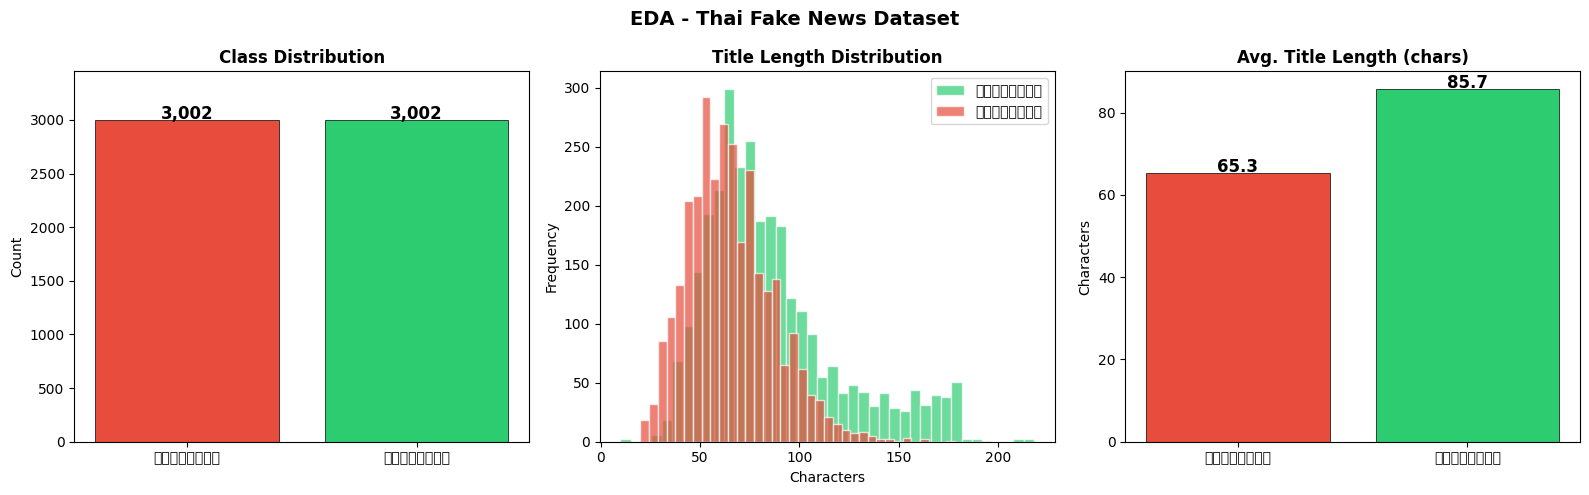

✅ EDA เสร็จสิ้น


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA - Thai Fake News Dataset', fontsize=14, fontweight='bold')

colors = {'real': '#2ecc71', 'fake': '#e74c3c'}
label_display = {'real': 'ข่าวจริง', 'fake': 'ข่าวปลอม'}

# 1. Class Distribution
ax1 = axes[0]
counts = df['label_name'].value_counts()
bars = ax1.bar(
    [label_display[l] for l in counts.index],
    counts.values,
    color=[colors[l] for l in counts.index],
    edgecolor='black', linewidth=0.5
)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) * 1.15)

# 2. Title Length Distribution
ax2 = axes[1]
df['title_len'] = df['text'].apply(len)
for label, color in [('real', '#2ecc71'), ('fake', '#e74c3c')]:
    data = df[df['label_name'] == label]['title_len']
    ax2.hist(data, bins=40, alpha=0.7, color=color,
             label=label_display[label], edgecolor='white')
ax2.set_title('Title Length Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Characters')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Average Title Length
ax3 = axes[2]
avg_len = df.groupby('label_name')['title_len'].mean()
bars3 = ax3.bar(
    [label_display[l] for l in avg_len.index],
    avg_len.values,
    color=[colors[l] for l in avg_len.index],
    edgecolor='black', linewidth=0.5
)
for bar, val in zip(bars3, avg_len.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Avg. Title Length (chars)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Characters')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA เสร็จสิ้น')

## 🔤 Cell 5: Text Preprocessing (ภาษาไทย)

In [5]:
import re
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords

STOPWORDS = set(thai_stopwords())

def preprocess_thai(text: str, remove_stopwords: bool = True) -> str:
    """Preprocess ข้อความภาษาไทย + ตัดคำ"""
    text = str(text)
    # ลบ URL, mention, hashtag
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    # ลบอักขระพิเศษ
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # ตัดคำภาษาไทย
    tokens = word_tokenize(text, engine='newmm')
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and t.strip()]
    return ' '.join(tokens)


print('🔄 กำลัง Preprocess ข้อความ...')
df['text_clean'] = df['text'].apply(preprocess_thai)
df['text_raw']   = df['text'].apply(lambda x: preprocess_thai(x, remove_stopwords=False))

print('✅ Preprocess เสร็จสิ้น')
print()
print('📌 ตัวอย่าง:')
for i in range(3):
    print(f'  [{df.original_label[i]}]')
    print(f'  Original : {df.text[i]}')
    print(f'  Cleaned  : {df.text_clean[i]}')
    print()

🔄 กำลัง Preprocess ข้อความ...
✅ Preprocess เสร็จสิ้น

📌 ตัวอย่าง:
  [ข่าวปลอม]
  Original :  กรมพัฒนาธุรกิจการค้าอนุญาตใบทะเบียนพาณิชย์รายบุคคล ประกอบธุรกิจเงินกู้นอกระบบแบบออนไลน์
  Cleaned  : กรม พัฒนา ธุร กิจการค้า อนุญาต ใบ ทะเบียน พาณิชย์ รายบุคคล ประกอบธุรกิจ เงินกู้ ระบบ ออนไลน์

  [ข่าวปลอม]
  Original :  กรมการจัดหางานส่งเสริมให้ชาวไทยมีรายได้ เฉลี่ย 1,500 – 3,900 บาทต่อวัน
  Cleaned  : กรมการจัดหางาน ส่งเสริม ชาวไทย รายได้ เฉลี่ย 1 500 3 900 บาท

  [ข่าวปลอม]
  Original :  ตลาดหลักทรัพย์แห่งประเทศไทยเปิดลงทุนเพื่อหาค่าข้าว วันละ 1,000 บาท ด้วยบิทคอยน์
  Cleaned  : ตลาดหลักทรัพย์ ประเทศ ไทย ลงทุน หา ค่า ข้าว 1 000 บาท บิท คอยน์



## ✂️ Cell 6: Train/Validation/Test Split

In [6]:
X = np.array(df['text_clean'].tolist())
y = np.array(df['label'].tolist())

# แบ่ง 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print('📊 Dataset Split:')
print(f'   Train : {len(X_train):,} samples ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Val   : {len(X_val):,} samples ({len(X_val)/len(X)*100:.0f}%)')
print(f'   Test  : {len(X_test):,} samples ({len(X_test)/len(X)*100:.0f}%)')

results = {}

📊 Dataset Split:
   Train : 4,202 samples (70%)
   Val   : 901 samples (15%)
   Test  : 901 samples (15%)


---
## 🟠 LSTM MODEL
---
## Cell 7: สร้าง Vocabulary

In [7]:
from collections import Counter

# สร้าง Vocabulary จาก training data
MAX_VOCAB = 15000
MAX_SEQ_LEN = 100
EMBED_DIM = 128
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def text_to_ids(text, vocab, max_len=MAX_SEQ_LEN):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    # Padding
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids


vocab = build_vocab(X_train)
print(f'📚 Vocabulary size: {len(vocab):,}')

# แปลงข้อความเป็น IDs
X_train_ids = np.array([text_to_ids(t, vocab) for t in X_train])
X_val_ids   = np.array([text_to_ids(t, vocab) for t in X_val])
X_test_ids  = np.array([text_to_ids(t, vocab) for t in X_test])

print(f'✅ Input shape: {X_train_ids.shape}')

📚 Vocabulary size: 7,174
✅ Input shape: (4202, 100)


## Cell 10: PyTorch Dataset & DataLoader

In [8]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
        self.lengths = (self.X != 0).sum(dim=1).clamp(min=1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.lengths[idx]


BATCH_SIZE = 64

train_ds = NewsDataset(X_train_ids, y_train)
val_ds   = NewsDataset(X_val_ids, y_val)
test_ds  = NewsDataset(X_test_ids, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'✅ DataLoader ready: {len(train_loader)} train batches')

✅ DataLoader ready: 66 train batches


## Cell 11: LSTM Model Architecture

In [9]:
from sklearn import metrics


class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 num_classes=2, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        direction = 2 if bidirectional else 1
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * direction, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, lengths):
        emb = self.dropout_emb(self.embedding(x))   # (B, L, E)

        # Pack sequence
        packed = pack_padded_sequence(emb, lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            # concat forward + backward last hidden
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]

        return self.fc(hidden)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch, lengths in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, targets, probs = [], [], []
    for X_batch, y_batch, lengths in loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(X_batch, lengths)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds.extend(logits.argmax(1).cpu().numpy())
        targets.extend(y_batch.numpy())
        probs.extend(prob)
    return np.array(preds), np.array(targets), np.array(probs)


def train_lstm_model(model_name, bidirectional=False, epochs=20):
    print(f'\n{'='*55}')
    print(f'🟠 MODEL: {model_name}')
    print(f'{'='*55}')

    model = LSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=256,
        num_layers=2,
        num_classes=2,
        dropout=0.3,
        bidirectional=bidirectional
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_preds, val_targets, _ = evaluate(model, val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        scheduler.step(1 - val_acc)

        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name.lower().replace(" ","_")}_best.pt')

        if epoch % 2 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d}/{epochs} | Loss: {loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    train_time = time.time() - t0

    # โหลด best model แล้วประเมินบน test set
    model.load_state_dict(torch.load(f'{model_name.lower().replace(" ","_")}_best.pt',
                                      map_location=DEVICE))
    test_preds, test_targets, test_probs = evaluate(model, test_loader)

    metrics = {
        'accuracy': accuracy_score(test_targets, test_preds),
        'f1': f1_score(test_targets, test_preds, average='weighted'),
        'auc': roc_auc_score(test_targets, test_probs),
        'train_time': train_time,
        'history': history,
        'test_preds': test_preds,
        'test_probs': test_probs
    }

    print(f'\n  📌 Test Results:')
    print(f'  Accuracy : {metrics["accuracy"]:.4f} ({metrics["accuracy"]*100:.2f}%)')
    print(f'  F1-Score : {metrics["f1"]:.4f}')
    print(f'  AUC-ROC  : {metrics["auc"]:.4f}')
    print(f'  Train Time: {train_time:.1f}s')
    print(classification_report(test_targets, test_preds, target_names=['Real', 'Fake']))

    metrics['model'] = model 
    
    return metrics


print('✅ โมเดล LSTM พร้อม')

✅ โมเดล LSTM พร้อม


## Cell 12: Train LSTM

In [10]:
lstm_metrics = train_lstm_model('LSTM', bidirectional=False, epochs=20)
results['LSTM'] = lstm_metrics

# เก็บ model object สำหรับ Demo
lstm_model = lstm_metrics['model']
print('✅ เก็บ lstm_model เรียบร้อย')


🟠 MODEL: LSTM
  Epoch 01/20 | Loss: 0.5769 | Train Acc: 0.6897 | Val Acc: 0.7503
  Epoch 02/20 | Loss: 0.4087 | Train Acc: 0.8125 | Val Acc: 0.8013
  Epoch 04/20 | Loss: 0.2556 | Train Acc: 0.8915 | Val Acc: 0.8446
  Epoch 06/20 | Loss: 0.1708 | Train Acc: 0.9298 | Val Acc: 0.8413
  Epoch 08/20 | Loss: 0.1153 | Train Acc: 0.9560 | Val Acc: 0.8424
  Epoch 10/20 | Loss: 0.0825 | Train Acc: 0.9686 | Val Acc: 0.8635
  Epoch 12/20 | Loss: 0.0573 | Train Acc: 0.9802 | Val Acc: 0.8457
  Epoch 14/20 | Loss: 0.0367 | Train Acc: 0.9876 | Val Acc: 0.8657
  Epoch 16/20 | Loss: 0.0226 | Train Acc: 0.9917 | Val Acc: 0.8657
  Epoch 18/20 | Loss: 0.0145 | Train Acc: 0.9952 | Val Acc: 0.8635
  Epoch 20/20 | Loss: 0.0161 | Train Acc: 0.9948 | Val Acc: 0.8635

  📌 Test Results:
  Accuracy : 0.8546 (85.46%)
  F1-Score : 0.8545
  AUC-ROC  : 0.9382
  Train Time: 188.5s
              precision    recall  f1-score   support

        Real       0.84      0.88      0.86       451
        Fake       0.88      0

---
## 📊 ผลการทดลอง LSTM
---

In [11]:
# ========== Summary Table ==========
summary = []
for model_name, m in results.items():
    summary.append({
        'Model': model_name,
        'Accuracy (%)': round(m['accuracy'] * 100, 2),
        'F1-Score': round(m['f1'], 4),
        'AUC-ROC': round(m['auc'], 4),
        'Train Time (s)': round(m['train_time'], 1)
    })

summary_df = pd.DataFrame(summary)
print('='*55)
print('📊 LSTM MODEL RESULTS')
print('='*55)
print(summary_df.to_string(index=False))
print('='*55)
print(f'\n🏆 Accuracy : {lstm_metrics["accuracy"]*100:.2f}%')
print(f'🏆 F1-Score  : {lstm_metrics["f1"]:.4f}')
print(f'🏆 AUC-ROC   : {lstm_metrics["auc"]:.4f}')

📊 LSTM MODEL RESULTS
Model  Accuracy (%)  F1-Score  AUC-ROC  Train Time (s)
 LSTM         85.46    0.8545   0.9382           188.5

🏆 Accuracy : 85.46%
🏆 F1-Score  : 0.8545
🏆 AUC-ROC   : 0.9382


## 📊 Visualization - ผลการทดลอง LSTM

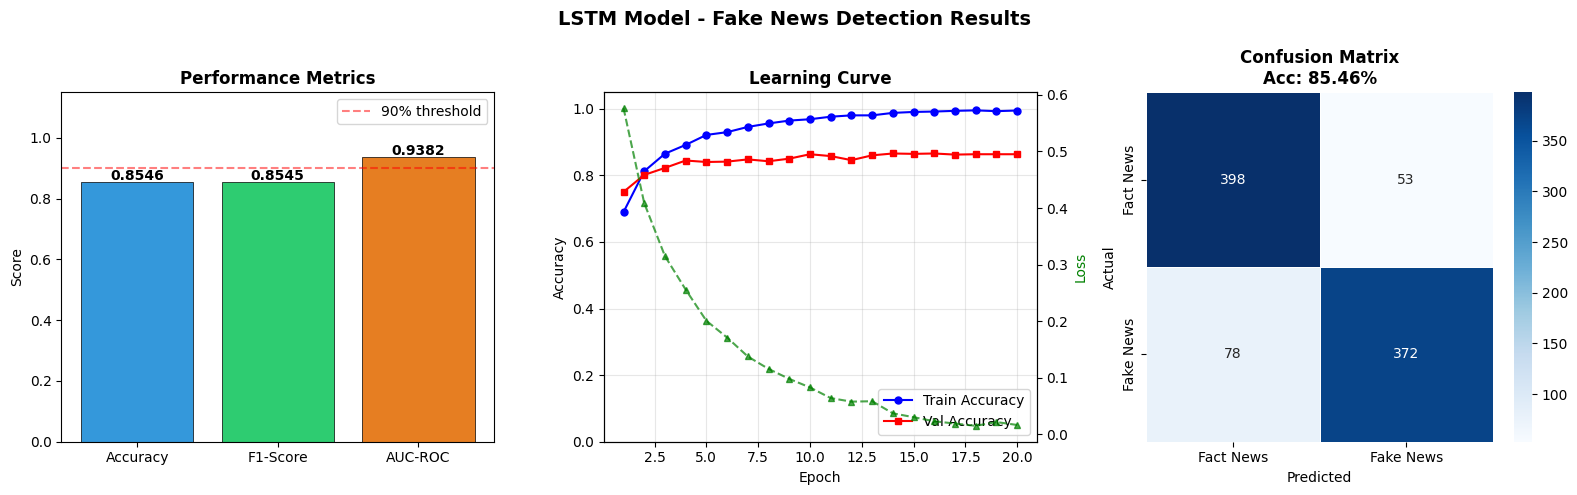

✅ บันทึกกราฟ lstm_results.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LSTM Model - Fake News Detection Results', fontsize=14, fontweight='bold')

# 1. Accuracy / F1 / AUC Bar
ax1 = axes[0]
metrics_names = ['Accuracy', 'F1-Score', 'AUC-ROC']
metrics_vals  = [lstm_metrics['accuracy'], lstm_metrics['f1'], lstm_metrics['auc']]
bars = ax1.bar(metrics_names, metrics_vals, color=['#3498db','#2ecc71','#e67e22'],
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, metrics_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Performance Metrics', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% threshold')
ax1.legend()

# 2. Learning Curve
ax2 = axes[1]
history = lstm_metrics['history']
epochs = range(1, len(history['train_acc']) + 1)
ax2.plot(epochs, history['train_acc'], 'b-o', markersize=5, label='Train Accuracy')
ax2.plot(epochs, history['val_acc'],   'r-s', markersize=5, label='Val Accuracy')
ax2b = ax2.twinx()
ax2b.plot(epochs, history['train_loss'], 'g--^', markersize=4, label='Train Loss', alpha=0.7)
ax2b.set_ylabel('Loss', color='green')
ax2.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix
ax3 = axes[2]
cm = confusion_matrix(y_test, lstm_metrics['test_preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Fact News', 'Fake News'],
            yticklabels=['Fact News', 'Fake News'],
            linewidths=0.5)
ax3.set_title(f'Confusion Matrix\nAcc: {lstm_metrics["accuracy"]:.2%}',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึกกราฟ lstm_results.png')

## 📊 Classification Report

In [13]:
print('='*55)
print('📋 Classification Report - LSTM')
print('='*55)
print(classification_report(y_test, lstm_metrics['test_preds'],
                             target_names=['Fact News', 'Fake News']))

📋 Classification Report - LSTM
              precision    recall  f1-score   support

   Fact News       0.84      0.88      0.86       451
   Fake News       0.88      0.83      0.85       450

    accuracy                           0.85       901
   macro avg       0.86      0.85      0.85       901
weighted avg       0.86      0.85      0.85       901



## 🎯 สรุปผล

In [14]:
print('='*55)
print('🎯 สรุปผลการทดลอง LSTM - Fake News Detection')
print('='*55)
print(f'  Dataset   : data_notagword_v1.csv ({len(df):,} samples)')
print(f'  Train/Val/Test: 70/15/15')
print(f'  Accuracy  : {lstm_metrics["accuracy"]*100:.2f}%')
print(f'  F1-Score  : {lstm_metrics["f1"]:.4f}')
print(f'  AUC-ROC   : {lstm_metrics["auc"]:.4f}')
print(f'  Train Time: {lstm_metrics["train_time"]:.1f}s')
print()
print('  โมเดล: LSTM 2 layers, Hidden=256, Embedding=128')
print('  Optimizer: Adam lr=1e-3')
print('  Epochs: 10')

🎯 สรุปผลการทดลอง LSTM - Fake News Detection
  Dataset   : data_notagword_v1.csv (6,004 samples)
  Train/Val/Test: 70/15/15
  Accuracy  : 85.46%
  F1-Score  : 0.8545
  AUC-ROC   : 0.9382
  Train Time: 188.5s

  โมเดล: LSTM 2 layers, Hidden=256, Embedding=128
  Optimizer: Adam lr=1e-3
  Epochs: 10


## 🎮 Demo - ทดสอบกับข่าวใหม่

In [15]:
print('='*70)
print('🎯 สรุปผลการทดลอง: การตรวจสอบข่าวปลอมด้วย LSTM')
print('='*70)
print(f'  Accuracy : {lstm_metrics["accuracy"]*100:.2f}%')
print(f'  F1-Score : {lstm_metrics["f1"]:.4f}')
print(f'  AUC-ROC  : {lstm_metrics["auc"]:.4f}')
print()
print('='*70)

🎯 สรุปผลการทดลอง: การตรวจสอบข่าวปลอมด้วย LSTM
  Accuracy : 85.46%
  F1-Score : 0.8545
  AUC-ROC  : 0.9382



## 🎮 Demo - ทดสอบกับข่าวใหม่

In [28]:
def predict_fake_news(text: str):
    """ทำนายว่าข่าวเป็นจริงหรือปลอมด้วย LSTM"""
    text_clean = preprocess_thai(text)

    ids = text_to_ids(text_clean, vocab)
    x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    length = torch.tensor([(x != 0).sum().item()]).clamp(min=1)

    lstm_model.eval()
    with torch.no_grad():
        logits = lstm_model(x, length)
        prob = torch.softmax(logits, dim=1)[0]
        pred = logits.argmax(1).item()
        confidence = prob[pred].item()

    label = '🚨 ข่าวปลอม (FAKE)' if pred == 1 else '✅ ข่าวจริง (REAL)'
    print(f'📰 ข้อความ  : {text}')
    print(f'   ผลลัพธ์  : {label}')
    print(f'   ความมั่นใจ: {confidence:.2%}')
    print()


# ทดสอบ
print('='*65)
print('🎮 DEMO: ทดสอบตรวจจับข่าวปลอม (LSTM)')
print('='*65)

test_news = [
    'กกต. โกงการเลือกตั้ง ประชาชนโวย ต้องการเลือกตั้งใหม่',
    'มีนักศึกษาปล่อยเงินกู้เงินดอกเบี้ย0.1% ต่อเดือน ไม่ต้องมีหลักประกัน',
    'นายกแจกเงินประชาชนทุกคนคนละ 10,000 บาท เริ่ม 1 มีนาคมนี้',
    'มีนักศึกษาชาย ตัวย่อ เกม จากสถาบันไทย-ญี่ปุ่น ถูกจับข้อหาปลอมแปลงเอกสารเพื่อสมัครงาน',

]

for news in test_news:
    predict_fake_news(news)

🎮 DEMO: ทดสอบตรวจจับข่าวปลอม (LSTM)
📰 ข้อความ  : กกต. โกงการเลือกตั้ง ประชาชนโวย ต้องการเลือกตั้งใหม่
   ผลลัพธ์  : ✅ ข่าวจริง (REAL)
   ความมั่นใจ: 98.11%

📰 ข้อความ  : มีนักศึกษาปล่อยเงินกู้เงินดอกเบี้ย0.1% ต่อเดือน ไม่ต้องมีหลักประกัน
   ผลลัพธ์  : 🚨 ข่าวปลอม (FAKE)
   ความมั่นใจ: 99.86%

📰 ข้อความ  : นายกแจกเงินประชาชนทุกคนคนละ 10,000 บาท เริ่ม 1 มีนาคมนี้
   ผลลัพธ์  : 🚨 ข่าวปลอม (FAKE)
   ความมั่นใจ: 99.99%

📰 ข้อความ  : มีนักศึกษาชาย ตัวย่อ เกม จากสถาบันไทย-ญี่ปุ่น ถูกจับข้อหาปลอมแปลงเอกสารเพื่อสมัครงาน
   ผลลัพธ์  : ✅ ข่าวจริง (REAL)
   ความมั่นใจ: 99.61%

